# CO2 Emmissions by cars 


## **Project Definition and Goal**<br>  <span style="color: red;">Imrpove</span>




### Identifying the car technical characteristics that play a role in pollution 

<span style="font-size: 18px">

- This project aims to identify which technical characteristics<br>
of newly registered vehicles most influence their CO₂ emissions.<br>
Our goal is to uncover patterns and predictors of emissions<br>
performance that can inform sustainable vehicle design, <br>
manufacturing strategies, and environmental policy<br>

<br>
    To develop a robust and well-tested approach, we begin<br>
with a focused exploratory analysis using a 2013 dataset<br>
of cars sold in France. Once the analytical pipeline<br>
is validated on this smaller, simpler dataset,<br>
we will apply the same methodology to the<br>
full-scale European Environment Agency (EEA) 2023<br> dataset.
This ensures both efficiency in development and <br>
relevance in our final insights.<br>

## **Datasets Overview**



We'll begin our study with two datasets:

### 1. **France 2013 dataset** (initial EDA phase)

- Contains technical and environmental specifications of passenger cars sold in France in 2013  
- Includes CO₂ emissions, fuel consumption, engine power, mass, and fuel type  
- Used to prototype visualizations, hypothesis tests, and feature selection  

### 2. **EEA 2023 dataset** (main analysis phase)

- Covers all new passenger cars registered in the European Union in 2023  
- Includes updated WLTP-based CO₂ measurements and richer technical data  
- Used to produce the final results and insights relevant to current EU mobility trends  

### Column Descriptions — 2023 EEA <span style="color: red;">improve.</span>



| Name          | Definition                                                                                                |
| ------------- | --------------------------------------------------------------------------------------------------------- |
| ID            | Identification number.                                                                                    |
| MS            | Member state.                                                                                             |
| Mp            | Manufacturer pooling.                                                                                     |
| VFN           | Vehicle family identification number.                                                                     |
| Mh            | Manufacturer name EU standard denomination .                                                              |
| Man           | Manufacturer name OEM declaration.                                                                        |
| MMS           | Manufacturer name MS registry denomination .                                                              |
| TAN           | Type approval number.                                                                                     |
| T             | Type.                                                                                                     |
| Va            | Variant.                                                                                                  |
| Ve            | Version.                                                                                                  |
| Mk            | Make.                                                                                                     |
| Cn            | Commercial name.                                                                                          |
| Ct            | Category of the vehicle type approved.                                                                    |
| Cr            | Category of the vehicle registered.                                                                       |
| M (kg)        | Mass in running order Completed/complete vehicle .                                                        |
| Mt            | WLTP test mass.                                                                                           |
| Enedc (g/km)  | Specific CO2 Emissions (NEDC).                                                                            |
| Ewltp (g/km)  | Specific CO2 Emissions (WLTP).                                                                            |
| W (mm)        | Wheel Base.                                                                                               |
| At1 (mm)      | Axle width steering axle.                                                                                 |
| At2 (mm)      | Axle width other axle.                                                                                    |
| Ft            | Fuel type.                                                                                                |
| Fm            | Fuel mode.                                                                                                |
| Ec (cm3)      | Engine capacity.                                                                                          |
| Ep (KW)       | Engine power.                                                                                             |
| Z (Wh/km)     | Electric energy consumption.                                                                              |
| IT            | Innovative technology or group of innovative technologies.                                                |
| Ernedc (g/km) | Emissions reduction through innovative technologies.                                                      |
| Erwltp (g/km) | Emissions reduction through innovative technologies (WLTP).                                               |
| De            | Deviation factor.                                                                                         |
| Vf            | Verification factor.                                                                                      |
| R             | Total new registrations.                                                                                  |
| Year          | Reporting year.                                                                                           |
| Status        | P = Provisional data, F = Final data.                                                                     |
| Version_file  | Internal versioning of deliverables.                                                                      |
| E (g/km)      | Specific CO2 Emission. Deprecated value, only relevant for data until 2016.                               |
| Er (g/km)     | Emissions reduction through innovative technologies. Deprecated value, only relevant for data until 2016. |
| Zr            | Electric range.                                                                                           |
| Dr            | Registration date.                                                                                        |
| Fc            | Fuel consumption.                                                                                         |


## **Data Loading**

In [118]:
### importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [119]:

# 2023 France Database into df_a_a_a 

df_a = pd.read_csv('../data/raw/data_2023.csv', sep=',', encoding='utf-8')

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_56298/1031381680.py:3: DtypeWarning: Columns (2,3,28,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_a = pd.read_csv('../data/raw/data_2023.csv', sep=',', encoding='utf-8')


## **First Data Exploration of Europe 2023 Data Set**

### Data Information

<span style="font-size: 16px">

#### 2023 Europe Data Frame Exploration

In [120]:
#df infos
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734656 entries, 0 to 10734655
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               object 
 2   VFN                   object 
 3   Mp                    object 
 4   Mh                    object 
 5   Man                   object 
 6   MMS                   float64
 7   Tan                   object 
 8   T                     object 
 9   Va                    object 
 10  Ve                    object 
 11  Mk                    object 
 12  Cn                    object 
 13  Ct                    object 
 14  Cr                    object 
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          float64
 20  W (mm)                float64
 21  At1 (mm)              float64
 22  At2 (mm)              float64
 23  Ft   

The following variables don't appear in the variables explanation in the EEA website </span>
- ech
- RLFI

Let's see how our table looks like

In [121]:
#extended version of the code
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

display(df_a.head())

df_a.tail()

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,130815554,DE,IP-MQB37SZ_A3_0550-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,e13*2007/46*1845*26,A1,DLAAX0AC4,FM6FM6AJ0254BI1CANNI02GA0,VOLKSWAGEN VW,T-ROC,M1,M1,1,1301.0,1414.0,NaN,143.0,NaN,NaN,NaN,petrol,M,999.0,81.0,NaN,e13 29,NaN,1.2,NaN,NaN,P,2023,2023-05-11,6.3,NaN,RL-MQ200_6F_18_019-WVW-1,NaN
1,130815555,DE,IP-0500709-TMA-1,HYUNDAI MOTOR EUROPE,HYUNDAI CZECH,HYUNDAI MOTOR MANUFACTURING CZECH SRO,NaN,e5*2018/858*00001*06,NX4E,F5P44,A61B14,HYUNDAI,TUCSON IX35,M1,M1,1,1709.0,1852.0,NaN,145.0,NaN,NaN,NaN,petrol,H,1598.0,132.0,NaN,e5 28,NaN,0.8,NaN,NaN,P,2023,2023-10-10,6.4,NaN,RL-0500710-TMA-1,NaN
2,130815556,DE,IP-03_312_0344-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,NaN,e3*2007/46*0064*69,312,AYD1B,AAA,FIAT,FIAT 500,M1,M1,1,1043.0,1135.0,NaN,106.0,NaN,NaN,NaN,petrol,H,999.0,52.0,NaN,e3 33,NaN,1.3,NaN,NaN,P,2023,2023-08-29,4.7,NaN,RL-03_312_0110-ZFA-1,NaN
3,130815557,DE,IP-FBC1NBPTL4C_000-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,NaN,e2*2007/46*0546*32,RFB,BF2,NB6UCB430100,RENAULT,MEGANE,M1,M1,1,1316.0,1432.0,NaN,131.0,NaN,NaN,NaN,petrol,M,1332.0,103.0,NaN,e9 29 37,NaN,1.9,NaN,NaN,P,2023,2023-12-18,5.8,NaN,RL-FBCTL6A_300_000-VF1-1,NaN
4,130815558,DE,IP-MLB49_Z_B0_0694-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,NaN,e1*2001/116*0430*91,B8,A2DTPAQ1,QD7AD7CJ003RT081E19S54BIBEM1CD1,AUDI,A4 AVANT,M1,M1,1,1700.0,1866.0,NaN,158.0,NaN,NaN,NaN,diesel,H,1968.0,150.0,NaN,e13 33 37,NaN,2.0,NaN,NaN,P,2023,2023-11-20,6.0,NaN,RL-DL382_7A_19_013-WAU-1,NaN


,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
10734651,134791605,PT,IP-EHT____ML6_722D-YAR-0,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e2*2007/46*0537*19,V,E,EHTM-P2S20L(1V),TOYOTA,PROACE,M1,M1,1,1808.0,2140.0,NaN,193.0,NaN,NaN,NaN,DIESEL,M,1997.0,106.0,NaN,e2 33,NaN,1.1,NaN,NaN,P,2023,2023-12-28,7.4,NaN,NaN,NaN
10734652,134793098,PT,IP-0200-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0318*07,ZE1HE(EU M),ZWE219(W),ZWE219L-DWXNBW(2H),TOYOTA,TOYOTA COROLLA,M1,M1,1,1475.0,1574.0,NaN,106.0,NaN,NaN,NaN,PETROL,H,1798.0,72.0,NaN,e6 37,NaN,0.6,NaN,NaN,P,2023,2023-09-01,4.7,NaN,NaN,NaN
10734653,134794448,PT,IP-0206-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA MOTOR CORPORATION,TOYOTA MOTOR CORPORATION,NaN,e6*2018/858*00260*00,XW6(M),MXWH61(H),MXWH61L-AHXHBW(1A),TOYOTA,TOYOTA PRIUS PHEV,M1,M1,1,1630.0,1753.0,NaN,16.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,1987.0,111.0,126.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-11-16,0.7,NaN,NaN,72.0
10734654,134795081,PT,IP-0120-JT1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0429*03,XA5P(EU M),AXAP54(N),AXAP54L-ANXGBW(1D),TOYOTA,TOYOTA RAV4,M1,M1,1,2005.0,2162.0,NaN,22.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,2487.0,136.0,171.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-12-21,1.0,NaN,NaN,75.0
10734655,134796702,PT,IP-0120-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0429*02,XA5P(EU M),AXAP54(N),AXAP54L-ANXGBW(1C),TOYOTA,TOYOTA RAV4,M1,M1,1,2005.0,2162.0,NaN,22.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,2487.0,136.0,166.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-10-31,1.0,NaN,NaN,75.0


### Data Translation

In [122]:
translations = {
    'ID': 'Vehicle_ID',
    'MS': 'Member_State_code',
    'Mp': 'Manufacturer_Pooling',
    'VFN': 'Vehicle_Family_id_number',
    'Mh': 'Manufacturer_Name',
    'Man': 'Manufacturer_name_OEM',
    'MMS': 'Manufacturer_name_MS',
    'Tan': 'Type_approval_number',
    'T': 'Type',
    'Va': 'Variant',
    'Ve': 'Version',
    'Mk': 'Make',
    'Cn': 'Commercial_Name',
    'Ct': 'Category_type_approved',
    'Cr': 'Category_type_registered',
    'r': 'Total_new_registrations',
    'm (kg)': 'Mass_in_Running_Order(kg)',
    'Mt': 'WLTP_test_mass',
    'Enedc (g/km)': 'CO2_Emissions_NEDC(g/km)',
    'Ewltp (g/km)': 'CO2_Emissions_WLTP(g/km)',
    'W (mm)': 'Wheelbase(mm)',
    'At1 (mm)': 'Axle_Track_1(mm)',
    'At2 (mm)': 'Axle_Track_2(mm)',
    'Ft': 'Fuel_Type',
    'Fm': 'Fuel_Mode',
    'ec (cm3)': 'Engine_Capacity(cm3)',
    'ep (KW)': 'Engine_Power(kW)',
    'z (Wh/km)': 'Electric_Energy_Consumption(Wh/km)',
    'IT': 'Innovative_Technologies',
    'Ernedc (g/km)': 'Emmission_reduction_through_innovation',
    'Erwltp (g/km)': 'Emmission_reduction_through_innovation_WLTP',
    'De': 'Deviation_factor',
    'Vf': 'Verification_factor',
    'ech': 'Electric_Charge',
    'Fuel consumption ':'Fuel_consumption',
    'Er (g/km)': 'CO2_Emissions(g/km)'
}



In [123]:
# Renaming columns
df_a.rename(columns=translations, inplace=True)

In [124]:
df_a.columns

Index(['Vehicle_ID', 'Country', 'Vehicle_Family_id_number',
       'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM',
       'Manufacturer_name_MS', 'Type_approval_number', 'Type', 'Variant',
       'Version', 'Make', 'Commercial_Name', 'Category_type_approved',
       'Category_type_registered', 'Total_new_registrations',
       'Mass_in_Running_Order(kg)', 'WLTP_test_mass',
       'CO2_Emissions_NEDC(g/km)', 'CO2_Emissions_WLTP(g/km)', 'Wheelbase(mm)',
       'Axle_Track_1(mm)', 'Axle_Track_2(mm)', 'Fuel_Type', 'Fuel_Mode',
       'Engine_Capacity(cm3)', 'Engine_Power(kW)',
       'Electric_Energy_Consumption(Wh/km)', 'Innovative_Technologies',
       'Emmission_reduction_through_innovation',
       'Emmission_reduction_through_innovation_WLTP', 'Deviation_factor',
       'Verification_factor', 'Status', 'year', 'Date of registration',
       'Fuel_consumption', 'Electric_Charge', 'RLFI', 'Electric range (km)'],
      dtype='object')

### Handle Variables that have 100% null values

In [125]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734656 entries, 0 to 10734655
Data columns (total 40 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Vehicle_ID                                   int64  
 1   Country                                      object 
 2   Vehicle_Family_id_number                     object 
 3   Manufacturer_Pooling                         object 
 4   Manufacturer_Name                            object 
 5   Manufacturer_name_OEM                        object 
 6   Manufacturer_name_MS                         float64
 7   Type_approval_number                         object 
 8   Type                                         object 
 9   Variant                                      object 
 10  Version                                      object 
 11  Make                                         object 
 12  Commercial_Name                              object 
 13  Category_t

In [126]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df_a.columns,
    'Data Type': df_a.dtypes,
    'Non-Null Count': df_a.count(),
    'Null Count': df_a.isnull().sum(),
    'Null Percentage': (df_a.isnull().sum() / len(df_a) * 100).round(2)
})
print(df_info.to_string(index=False))

                                     Column Data Type  Non-Null Count  Null Count  Null Percentage
                                 Vehicle_ID     int64        10734656           0              0.0
                                    Country    object        10734656           0              0.0
                   Vehicle_Family_id_number    object        10141479      593177              5.5
                       Manufacturer_Pooling    object         9777534      957122              8.9
                          Manufacturer_Name    object        10734656           0              0.0
                      Manufacturer_name_OEM    object        10734656           0              0.0
                       Manufacturer_name_MS   float64               0    10734656            100.0
                       Type_approval_number    object        10702002       32654              0.3
                                       Type    object        10728379        6277              0.1
          

<span style="color: orange;">Missing Data Analysis - Key Insights:</span>

As the following columns are NA, they will be dropped

- Manufacturer_name_MS
- CO2_Emissions_NEDC(g/km)
- Wheelbase(mm)
- Axle_Track_1(mm)
- Axle_Track_2(mm)
- Emmission_reduction_through_innovation
- Deviation_factor
- Verification_factor

**Electric Vehicle Features (High Missing %):**

- Electric_Energy_Consumption(Wh/km) - 78% missing
- Electric range (km) - 78% missing
- Electric_Charge - 64% missing
- RLFI - 70% missing

Reason: most probably the non-Electric Vehicles do not have the respective features. 

**Important Features (Moderate Missing):**

- Engine_Capacity(cm3) - 15.56% missing
- Fuel consumption - 29.65% missing
- WLTP_test_mass - 4.88% missing

**Clean Features (Low Missing):**

- CO2_Emissions_WLTP(g/km) - 0.19% missing (our target feature)


In [127]:
columns_to_drop = [
    'Manufacturer_name_MS',
    'CO2_Emissions_NEDC(g/km)',
    'Wheelbase(mm)',
    'Axle_Track_1(mm)',
    'Axle_Track_2(mm)',
    'Emmission_reduction_through_innovation',
    'Deviation_factor',
    'Verification_factor'
]

df_a = df_a.drop(columns=columns_to_drop)


In [128]:
# Drop rows where target variable has NaN/NA values
df_a = df_a.dropna(subset=['CO2_Emissions_WLTP(g/km)'])

### Handling duplicates

In [129]:
# Duplicates in the DataFrame and their percentage  

duplicates_count = df_a.duplicated().sum()
duplicates_percentage = (duplicates_count / len(df_a) * 100).round(2)
print(f"Number of duplicates: {duplicates_count} ({duplicates_percentage}%)")

Number of duplicates: 0 (0.0%)


There are no duplicates to handle for the next steps

### Categorical variables exploration



In [130]:
categorical_columns = df_a.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_columns)}")

for col in categorical_columns:
    unique_count = df_a[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    
    # Get value counts and percentages
    value_counts = df_a[col].value_counts()
    percentages = df_a[col].value_counts(normalize=True) * 100
    
    if unique_count <= 10:
        print(f"  - All values with distribution:")
        display_data = list(zip(value_counts.index, value_counts.values, percentages.values))
    else:
        print(f"  - Top 10 values with distribution:")
        display_data = list(zip(value_counts.head(10).index, value_counts.head(10).values, percentages.head(10).values))
    
    for val, count, pct in display_data:
        print(f"    {val}: {count} ({pct:.1f}%)")

Categorical columns found: ['Country', 'Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Type_approval_number', 'Type', 'Variant', 'Version', 'Make', 'Commercial_Name', 'Category_type_approved', 'Category_type_registered', 'Fuel_Type', 'Fuel_Mode', 'Innovative_Technologies', 'Status', 'Date of registration', 'Electric_Charge', 'RLFI']

Country:
  - Unique values: 29
  - Top 10 values with distribution:
    DE: 2754276 (25.7%)
    FR: 1889599 (17.6%)
    IT: 1563057 (14.6%)
    ES: 974227 (9.1%)
    BE: 475470 (4.4%)
    PL: 474293 (4.4%)
    NL: 364750 (3.4%)
    SE: 294410 (2.7%)
    AT: 238542 (2.2%)
    CZ: 217151 (2.0%)

Vehicle_Family_id_number:
  - Unique values: 8637
  - Top 10 values with distribution:
    IP-03_312_0344-ZFA-1: 191789 (1.9%)
    IP-0153-JT1-1: 118953 (1.2%)
    IP-0110-JT1-1: 94937 (0.9%)
    IP-JAA1MTPJT4A_000-VF1-1: 82074 (0.8%)
    IP-JFB1MTGJT4A_000-UU1-0: 69012 (0.7%)
    IP-HMH____MA5_5312-VR3-0: 62615 (0.6

<span style="color: orange;">Conclusions on Categorical Variables</span>


- Hierarchy of a car category is represented as following. 
    - Make
    - Commercial Name 
    - Type 
    - Variant
    - Version
    - Example: FIAT PANDA 312 PYDB1 BB5

- The following categorical variables are not interpretable as they are mostly technical references
    - Vehicle_Family_id_number
    - Type_approval_number
    - Category_type_approved
    - Category_type_registered
    - Innovative_Technologies
    - RLFI

- No dominancy has been observed to cause data imbalance 

### Modalities of Fuel Type reduction

In [131]:
# Create a mapping dictionary for standardization
fuel_mapping = {
    'PETROL': 'petrol',
    'DIESEL': 'diesel', 
    'ELECTRIC': 'electric',
    'PETROL/ELECTRIC': 'petrol/electric',
    'LPG': 'lpg',
    'e85': 'petrol'
}

# Apply the mapping
df_a['Fuel_Type'] = df_a['Fuel_Type'].replace(fuel_mapping)

# Check the result
print(df_a['Fuel_Type'].value_counts())

Fuel_Type
petrol             6049317
diesel             1821115
electric           1669450
petrol/electric     826398
lpg                 309129
diesel/electric      30264
ng                    7362
hydrogen               730
Name: count, dtype: int64


### Exploring numerical features

In [132]:
pd.set_option('display.float_format', '{:.1f}'.format)
# Displaying descriptive statistics of the DataFrame
df_a.describe()

,Vehicle_ID,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Emmission_reduction_through_innovation_WLTP,year,Fuel_consumption,Electric range (km)
count,10713765.0,10713765.0,10713365.0,10205226.0,10713765.0,9043496.0,10678848.0,2359609.0,5767272.0,10713765.0,7547786.0,2334701.0
mean,125983907.2,1.0,1545.6,1655.8,106.7,1543.2,115.2,171.9,1.5,2023.0,5.4,318.2
std,8060129.8,0.0,360.7,374.1,59.6,524.2,62.4,28.9,0.5,0.0,1.8,191.8
min,90240411.0,1.0,563.0,615.0,0.0,658.0,8.0,11.0,0.5,2023.0,0.1,12.0
25%,122188940.0,1.0,1270.0,1376.0,101.0,1197.0,74.0,155.0,1.1,2023.0,4.9,77.0
50%,128890021.0,1.0,1480.0,1584.0,123.0,1497.0,100.0,166.0,1.7,2023.0,5.5,380.0
75%,131879745.0,1.0,1765.0,1881.0,139.0,1968.0,132.0,179.0,2.0,2023.0,6.1,491.0
max,134796702.0,1.0,4953.0,4574.0,543.0,7993.0,1177.0,547.0,7.0,2023.0,29.0,883.0


The following numerical variable have only 1 value and hese variables are candidate to drop. They will be dropped in the next steps
- Total_new_registrations
- year

In [133]:
df_a.shape

(10713765, 32)

In [134]:
df_a.head(5)

,Vehicle_ID,Country,Vehicle_Family_id_number,Manufacturer_Pooling,Manufacturer_Name,Manufacturer_name_OEM,Type_approval_number,Type,Variant,Version,Make,Commercial_Name,Category_type_approved,Category_type_registered,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Innovative_Technologies,Emmission_reduction_through_innovation_WLTP,Status,year,Date of registration,Fuel_consumption,Electric_Charge,RLFI,Electric range (km)
0,130815554,DE,IP-MQB37SZ_A3_0550-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e13*2007/46*1845*26,A1,DLAAX0AC4,FM6FM6AJ0254BI1CANNI02GA0,VOLKSWAGEN VW,T-ROC,M1,M1,1,1301.0,1414.0,143.0,petrol,M,999.0,81.0,NaN,e13 29,1.2,P,2023,2023-05-11,6.3,NaN,RL-MQ200_6F_18_019-WVW-1,NaN
1,130815555,DE,IP-0500709-TMA-1,HYUNDAI MOTOR EUROPE,HYUNDAI CZECH,HYUNDAI MOTOR MANUFACTURING CZECH SRO,e5*2018/858*00001*06,NX4E,F5P44,A61B14,HYUNDAI,TUCSON IX35,M1,M1,1,1709.0,1852.0,145.0,petrol,H,1598.0,132.0,NaN,e5 28,0.8,P,2023,2023-10-10,6.4,NaN,RL-0500710-TMA-1,NaN
2,130815556,DE,IP-03_312_0344-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,e3*2007/46*0064*69,312,AYD1B,AAA,FIAT,FIAT 500,M1,M1,1,1043.0,1135.0,106.0,petrol,H,999.0,52.0,NaN,e3 33,1.3,P,2023,2023-08-29,4.7,NaN,RL-03_312_0110-ZFA-1,NaN
3,130815557,DE,IP-FBC1NBPTL4C_000-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,e2*2007/46*0546*32,RFB,BF2,NB6UCB430100,RENAULT,MEGANE,M1,M1,1,1316.0,1432.0,131.0,petrol,M,1332.0,103.0,NaN,e9 29 37,1.9,P,2023,2023-12-18,5.8,NaN,RL-FBCTL6A_300_000-VF1-1,NaN
4,130815558,DE,IP-MLB49_Z_B0_0694-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,e1*2001/116*0430*91,B8,A2DTPAQ1,QD7AD7CJ003RT081E19S54BIBEM1CD1,AUDI,A4 AVANT,M1,M1,1,1700.0,1866.0,158.0,diesel,H,1968.0,150.0,NaN,e13 33 37,2.0,P,2023,2023-11-20,6.0,NaN,RL-DL382_7A_19_013-WAU-1,NaN


### CO2 Analysis before Data Reduction

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_56298/3635154306.py:25: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


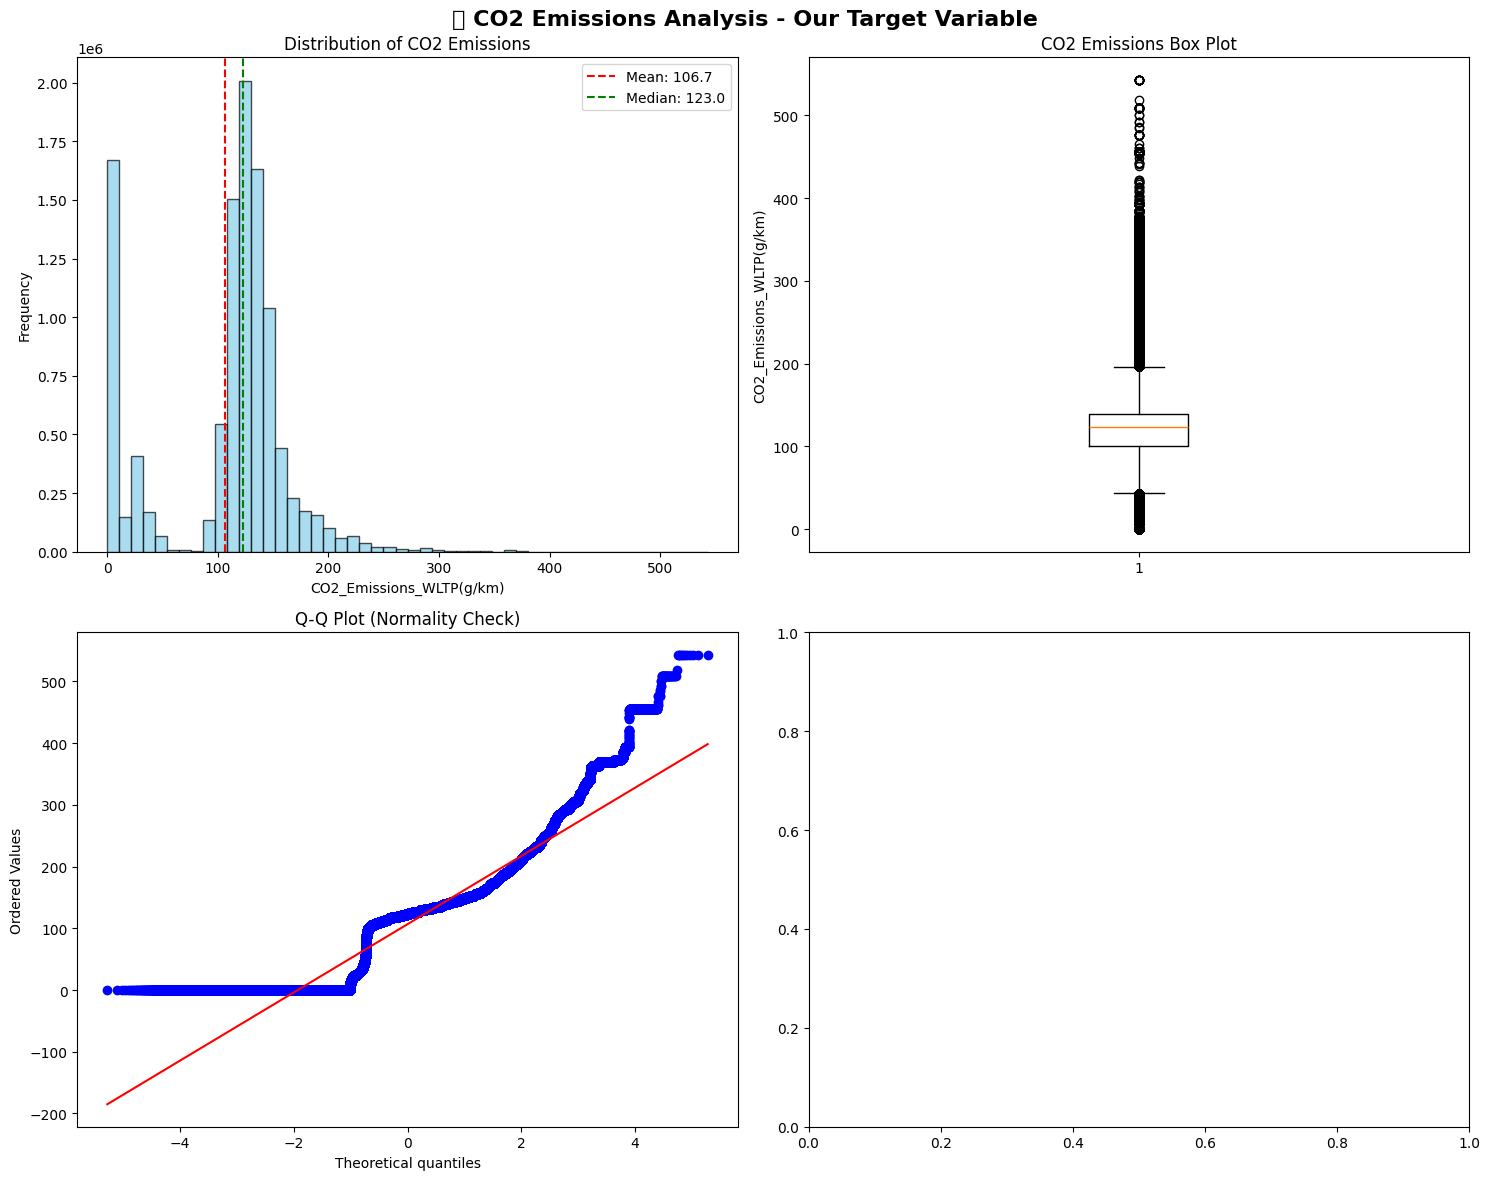

In [135]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df_a["CO2_Emissions_WLTP(g/km)"].mean():.1f}')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df_a["CO2_Emissions_WLTP(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2_Emissions_WLTP(g/km)')

# Q-Q plot for normality
stats.probplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')



plt.tight_layout()
plt.show()


Filtering for only Combustion motor cars are very crucial as Electronic ones have 0 and close to 0 values

## **Data Reduction**<br> 
- Filtering for "only Combustion" motor cars, using unique values <br> 
- selecting variables that make sense to study combustion <br>
- handling variables with high Zero content

### Filtering Petrol and Diesel

In [136]:
# Filtering the DataFrame to include only petrol and diesel vehicles
df_a = df_a[df_a['Fuel_Type'].isin(['petrol', 'diesel'])]

# Displaying the shape of the DataFrame after filtering
df_a.shape

(7870432, 32)

In [137]:
df_a['Fuel_Type'].value_counts()

Fuel_Type
petrol    6049317
diesel    1821115
Name: count, dtype: int64

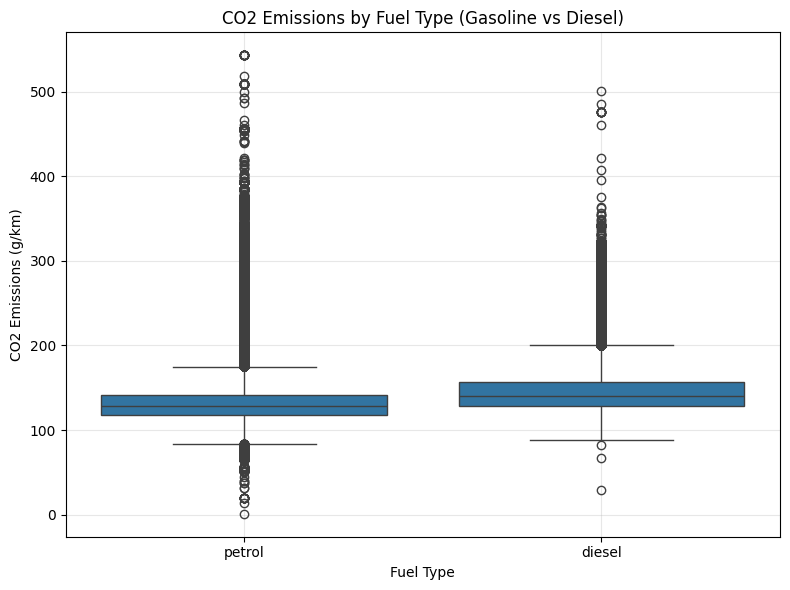

In [138]:
# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Fuel_Type', y='CO2_Emissions_WLTP(g/km)', data=df_a)
plt.title('CO2 Emissions by Fuel Type (Gasoline vs Diesel)')
plt.xlabel('Fuel Type')
plt.ylabel('CO2 Emissions (g/km)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Difference between Petrol and Diesel?

are petrol and diesel significant difference?

In [139]:
from scipy.stats import mannwhitneyu

# Filter data
co2_petrol = df_a[df_a['Fuel_Type'] == 'petrol']['CO2_Emissions_WLTP(g/km)']
co2_diesel = df_a[df_a['Fuel_Type'] == 'diesel']['CO2_Emissions_WLTP(g/km)']

# Perform Mann–Whitney U test
u_stat, p_value = mannwhitneyu(co2_petrol, co2_diesel, alternative='two-sided')

print("Mann–Whitney U Test")
print(f"U statistic = {u_stat}")
print(f"P-value = {p_value:.6f}")

# Interpret
alpha = 0.05
if p_value < alpha:
    print("✅ Statistically significant difference between petrol and diesel CO₂ emissions.")
else:
    print("❌ No statistically significant difference between petrol and diesel CO₂ emissions.")

Mann–Whitney U Test
U statistic = 3568378588742.0
P-value = 0.000000
✅ Statistically significant difference between petrol and diesel CO₂ emissions.


This is important to consider, we should keep this variable, because the CO2 Emissions are considerable different

### Filtering by Make + Commercial_Name + Type + Variant + Version

In [140]:
df_a['combined_5'] = df_a['Make'] + ' - ' + df_a['Commercial_Name'] + ' - ' + df_a['Type'] + ' - ' + df_a['Variant'] + ' - ' + df_a['Version']

df_a['combined_4'] = df_a['Commercial_Name'] + ' - ' + df_a['Type'] + ' - ' + df_a['Variant'] + ' - ' + df_a['Version']

df_a['combined_3'] =  df_a['Type'] + ' - ' + df_a['Variant'] + ' - ' + df_a['Version']

df_a['combined_2'] =   df_a['Variant'] + ' - ' + df_a['Version']

display(df_a['combined_5'].value_counts())

display(df_a['combined_4'].value_counts())

display(df_a['combined_3'].value_counts())

display(df_a['combined_2'].value_counts())

combined_5
CITROEN - C3 - S - XHMR - V/AMXS                                           47178
DACIA - SANDERO - DJF - BEV - M66UA43M5200                                 38767
FORD - PUMA - J2K - B7JB12X - 5CFHTNA5QAX                                  38168
RENAULT - AUSTRAL - RHN - HH1 - F25W16100000                               35244
FIAT - FIAT 500 - 312 - AYD1B - AAA                                        34859
                                                                           ...  
MERCEDES-BENZ - V 220 D - 639/2 - KLU6L310NXX - 2GJUDX28BEXX                   1
MERCEDES-BENZ - V 300 D - 639/2 - KLU7L310NXX - 2GJSDX27BELX                   1
BMW - X1 SDRIVE18I - F1X - 31AA - IAW500L0                                     1
OPEL - CORSA EDITION 15D DT MT6 S/S 100 CV (74KW) - U - B - YHTK-X2B300        1
HYUNDAI - TUCSON - NX4e - F5P11 - M61A14                                       1
Name: count, Length: 57444, dtype: int64

combined_4
C3 - S - XHMR - V/AMXS                                                    47355
SANDERO - DJF - BEV - M66UA43M5200                                        38767
PUMA - J2K - B7JB12X - 5CFHTNA5QAX                                        38168
MG ZS - SZS1 - 1AB1PA - JM5LIP                                            35365
AUSTRAL - RHN - HH1 - F25W16100000                                        35244
                                                                          ...  
ZAFIRA LIFE M BUSINESS ELEGANCE 20 DIESEL 180 CV - V - E - EHZ7-M2N20L        1
CADDY - SK - AFDPBCX0 - N230FD7FD7GC005N1N4BI1AA50N                           1
220D - F2GC - 51AM - IAW50800                                                 1
SPACETOURER JUMPY - KOPMR - EEHZ7C - P2N20L0                                  1
TUCSON - NX4e - F5P11 - M61A14                                                1
Name: count, Length: 53188, dtype: int64

combined_3
S - XHMR - V/AMXS                            56172
J2K - B7JB12X - 5CFHTNA5QAX                  45123
DJF - BEV - M66UA43M5200                     39035
XPB1F(M) - MXPJ10(H) - MXPJ10L-BHXNBW(DD)    38033
312 - AYD1B - AAA                            37230
                                             ...  
9YA - EF22 - 1204101                             1
9YA - 9YA - 1205101                              1
95B - JT22 - 250110                              1
992 - CD11 - 3400000                             1
NX4e - F5P11 - M61A14                            1
Name: count, Length: 35019, dtype: int64

combined_2
XHMR - V/AMXS                              56172
B7JB12X - 5CFHTNA5QAX                      45124
BEV - M66UA43M5200                         39035
MXPJ10(H) - MXPJ10L-BHXNBW(DD)             38485
AYD1B - AAA                                37230
                                           ...  
L2U31350BXX - RE3AB3A3XXGX                     1
ABCAVE - FD7FD7AM015LLSVR07MG                  1
KLU6L320NXX - 2GJSDXX6BEXX                     1
HLCDD0 - 7VCA050                               1
SXDXDBX0 - FD7SFD7CW0064B1VL1A18ADA8M15        1
Name: count, Length: 33692, dtype: int64

There is a huge gap between Combined 4 & Combined 3 that indicates the Commercial_Name varies even for the same vehicles. Therefore, it makes sense to move forward with **Type**,**Variant**,**Version** combination for the next steps

In [141]:
# droping the combined columns
df_a = df_a.drop(columns=['combined_5', 'combined_4', 'combined_3', 'combined_2'])

<span style="color: orange;">Final Column Decisions for dropping</span> <br>
Vehicle_Family_id_number - the model of the car is already described by other variables <br>
Manufacturer_Pooling - the model of the car is already described by other variables <br>
Manufacturer_Name - the model of the car is already described by other variables <br>
Manufacturer_name_OEM - the model of the car is already described by other variables <br>
Manufacturer_name_MS - the model of the car is already described by other variables <br>
Type_approval_number - the model of the car is already described by other variables <br>
Type - It will be used for filtering <br>
Variant - It will be used for filtering<br>
Version - It will be used for filtering <br>
Make - It will not be used for filtering due to many typos/different way of writing <br>
Commercial_Name - It will not be used for filtering due to many typos/different way of writing <br>
Category_type_approved - not relevant for CO2 <br>
Category_type_registered - not relevant for CO2 <br>
Total_new_registrations - not relevant for CO2 <br>
Mass_in_Running_Order(kg) - stay <br>
WLTP_test_mass - stay <br>
CO2_Emissions_NEDC(g/km) - the whole is zeros <br>
CO2_Emissions_WLTP(g/km) - our target <br>
Wheelbase(mm) - the whole is zeros <br>
Axle_Track_1(mm) - the whole is zeros <br>
Axle_Track_2(mm) - the whole is zeros<br>
Fuel_Type - we should keep it<br>
Fuel_Mode - stay<br>
Engine_Capacity(cm3) - stay<br>
Engine_Power(kW) - stay<br>
Electric_Energy_Consumption(Wh/km) - not relevant for Combustion<br>
Innovative_Technologies - 35% of zeros, delete<br>
Emmission_reduction_through_innovation - 30& of zeros, delete<br>
Emmission_reduction_through_innovation_WLTP - 30% of zeros, delete<br>
Deviation_factor - 100% of zeros, delete<br>
Verification_factor - 100% of zeros, delete<br>
Status - delete not relevant for study<br>
 year - delete not relevant for study<br>
Date of registration - delete, not relevant for study<br>
Fuel consumption - stay<br>
Electric_Charge - not relevant for Combustion<br>
RLFI - Delete, a lot of zeros
Electric range (km) - delete, not relevant for study<br>

## Applying Unique Values to find only unique auto models

In [142]:
df_unique = df_a.drop_duplicates(subset=['Version', 'Variant', 'Type','CO2_Emissions_WLTP(g/km)'])

In [143]:
df_a.shape

(7870432, 32)

In [144]:
df_unique.shape

(113821, 32)

In [145]:
df_unique.head(15)


,Vehicle_ID,Country,Vehicle_Family_id_number,Manufacturer_Pooling,Manufacturer_Name,Manufacturer_name_OEM,Type_approval_number,Type,Variant,Version,Make,Commercial_Name,Category_type_approved,Category_type_registered,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Innovative_Technologies,Emmission_reduction_through_innovation_WLTP,Status,year,Date of registration,Fuel_consumption,Electric_Charge,RLFI,Electric range (km)
0,130815554,DE,IP-MQB37SZ_A3_0550-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e13*2007/46*1845*26,A1,DLAAX0AC4,FM6FM6AJ0254BI1CANNI02GA0,VOLKSWAGEN VW,T-ROC,M1,M1,1,1301.0,1414.0,143.0,petrol,M,999.0,81.0,NaN,e13 29,1.2,P,2023,2023-05-11,6.3,NaN,RL-MQ200_6F_18_019-WVW-1,NaN
1,130815555,DE,IP-0500709-TMA-1,HYUNDAI MOTOR EUROPE,HYUNDAI CZECH,HYUNDAI MOTOR MANUFACTURING CZECH SRO,e5*2018/858*00001*06,NX4E,F5P44,A61B14,HYUNDAI,TUCSON IX35,M1,M1,1,1709.0,1852.0,145.0,petrol,H,1598.0,132.0,NaN,e5 28,0.8,P,2023,2023-10-10,6.4,NaN,RL-0500710-TMA-1,NaN
2,130815556,DE,IP-03_312_0344-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,e3*2007/46*0064*69,312,AYD1B,AAA,FIAT,FIAT 500,M1,M1,1,1043.0,1135.0,106.0,petrol,H,999.0,52.0,NaN,e3 33,1.3,P,2023,2023-08-29,4.7,NaN,RL-03_312_0110-ZFA-1,NaN
3,130815557,DE,IP-FBC1NBPTL4C_000-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,e2*2007/46*0546*32,RFB,BF2,NB6UCB430100,RENAULT,MEGANE,M1,M1,1,1316.0,1432.0,131.0,petrol,M,1332.0,103.0,NaN,e9 29 37,1.9,P,2023,2023-12-18,5.8,NaN,RL-FBCTL6A_300_000-VF1-1,NaN
4,130815558,DE,IP-MLB49_Z_B0_0694-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,e1*2001/116*0430*91,B8,A2DTPAQ1,QD7AD7CJ003RT081E19S54BIBEM1CD1,AUDI,A4 AVANT,M1,M1,1,1700.0,1866.0,158.0,diesel,H,1968.0,150.0,NaN,e13 33 37,2.0,P,2023,2023-11-20,6.0,NaN,RL-DL382_7A_19_013-WAU-1,NaN
5,130815559,DE,IP-MQB37SZ_A3_1035-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e13*2007/46*1845*27,A1,DXDBX0AC4,FD7FD7CW0064BI1CANNI02GA0,VOLKSWAGEN VW,T-ROC,M1,M1,1,1358.0,1487.0,144.0,petrol,M,1498.0,110.0,NaN,e13 29,1.2,P,2023,2023-07-12,6.4,NaN,RL-DQ200_7F_17_012-WVW-1,NaN
6,130815560,DE,IP-JFB1M6PJT4A_000-UU1-0,RENAULT-NISSAN-MITSUBISHI,DACIA,AUTOMOBILE DACIA SA,e19*2007/46*0026*15,DJF,BEV,M66UA43M5200,DACIA,SANDERO,M1,M1,1,1171.0,1258.0,127.0,petrol,M,999.0,67.0,NaN,e19 29 37,1.9,P,2023,2023-03-02,5.6,NaN,RL-JFAJT4A_220_000-UU1-0,NaN
7,130815561,DE,IP-MQB37WZ_A0_0591-TMB-1,VOLKSWAGEN,SKODA,SKODA AUTO AS,e8*2007/46*0355*12,NX,ACDTTCX0,NFD7FD7GC0024BIVL0C1A1A,SKODA,OCTAVIA,M1,M1,1,1478.0,1588.0,118.0,diesel,M,1968.0,110.0,NaN,e8 29 37,1.7,P,2023,2023-01-05,4.5,NaN,RL-DQ381_7F_19_001-WVW-1,NaN
9,130815563,DE,IP-AP992002GTSAT00-WP0-1,VOLKSWAGEN,PORSCHE,DR ING HCF PORSCHE AG,e13*2007/46*0992*15,992,CC12,3410000,PORSCHE,911 CARRERA GTS,M1,M1,1,1620.0,1742.0,247.0,petrol,M,2981.0,353.0,NaN,e1 33,0.9,P,2023,2023-10-17,10.9,NaN,RL-992002AT80ZZZ03-WP0-1,NaN
10,130815564,DE,IP-FCA1ALDDW6A_003-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,e2*2007/46*0470*22,RFC,JD4,ALAUA3P37000,RENAULT,ESPACE,M1,M1,1,1923.0,2102.0,167.0,diesel,M,1997.0,139.0,NaN,e2 29,1.1,P,2023,2023-01-05,6.4,NaN,RL-FCBDW6A_450_000-VF1-1,NaN


In [146]:
df_merged = df_a.groupby(['Version', 'Variant', 'Type', 'CO2_Emissions_WLTP(g/km)']).agg({
    'Mass_in_Running_Order(kg)': 'mean',
    'Fuel_Type': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'Fuel_Mode': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'Engine_Capacity(cm3)': 'mean',
    'Engine_Power(kW)': 'mean'
}).reset_index()

In [147]:
df_merged.shape 

(109658, 9)

In [148]:
df_merged.head(15)
#df_merged.tail(35)

,Version,Variant,Type,CO2_Emissions_WLTP(g/km),Mass_in_Running_Order(kg),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
0,-,-,BRONCO,254.0,2289.0,petrol,M,2694.0,246.0
1,-,-,BRONCO,257.0,2289.0,petrol,M,2694.0,246.0
2,-,-,BRONCO,285.0,2418.0,petrol,M,2694.0,246.0
3,-,-,BRONCO,288.0,2418.0,petrol,M,2694.0,246.0
4,-,-,C52X,178.0,1617.0,petrol,M,1498.0,130.0
5,-,-,M4,180.0,1790.0,petrol,M,1481.0,130.0
6,-,-,SX5G,162.0,NaN,petrol,M,1481.0,130.0
7,-,B,C51E,206.0,1505.0,petrol,M,1499.0,100.0
8,-,BRONCO,BRONCO,324.0,2289.0,petrol,M,2694.0,246.0
9,-,DXK7150KDH,FENGON 500-MT,171.0,1455.0,petrol,M,1498.0,78.0


### Exploring and selecting the rest of the variables (Merged with a strategy)

In [149]:
df_info = pd.DataFrame({
    'Column': df_merged.columns,
    'Data Type': df_merged.dtypes,
    'Non-Null Count': df_merged.count(),
    'Null Count': df_merged.isnull().sum(),
    'Null Percentage': (df_merged.isnull().sum() / len(df_merged) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
                  Version    object          109658           0              0.0
                  Variant    object          109658           0              0.0
                     Type    object          109658           0              0.0
 CO2_Emissions_WLTP(g/km)   float64          109658           0              0.0
Mass_in_Running_Order(kg)   float64          109636          22              0.0
                Fuel_Type    object          109658           0              0.0
                Fuel_Mode    object          109658           0              0.0
     Engine_Capacity(cm3)   float64          109656           2              0.0
         Engine_Power(kW)   float64          109622          36              0.0


In [150]:
df_merged_clean = df_merged.dropna()


In [151]:
df_info = pd.DataFrame({
    'Column': df_merged_clean.columns,
    'Data Type': df_merged_clean.dtypes,
    'Non-Null Count': df_merged_clean.count(),
    'Null Count': df_merged_clean.isnull().sum(),
    'Null Percentage': (df_merged_clean.isnull().sum() / len(df_merged_clean) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
                  Version    object          109598           0              0.0
                  Variant    object          109598           0              0.0
                     Type    object          109598           0              0.0
 CO2_Emissions_WLTP(g/km)   float64          109598           0              0.0
Mass_in_Running_Order(kg)   float64          109598           0              0.0
                Fuel_Type    object          109598           0              0.0
                Fuel_Mode    object          109598           0              0.0
     Engine_Capacity(cm3)   float64          109598           0              0.0
         Engine_Power(kW)   float64          109598           0              0.0


Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                           1.
Mass_in_Running_Order(kg)                          0.76
Engine_Power(kW)                                   0.68
Engine_Capacity(cm3)                               0.67


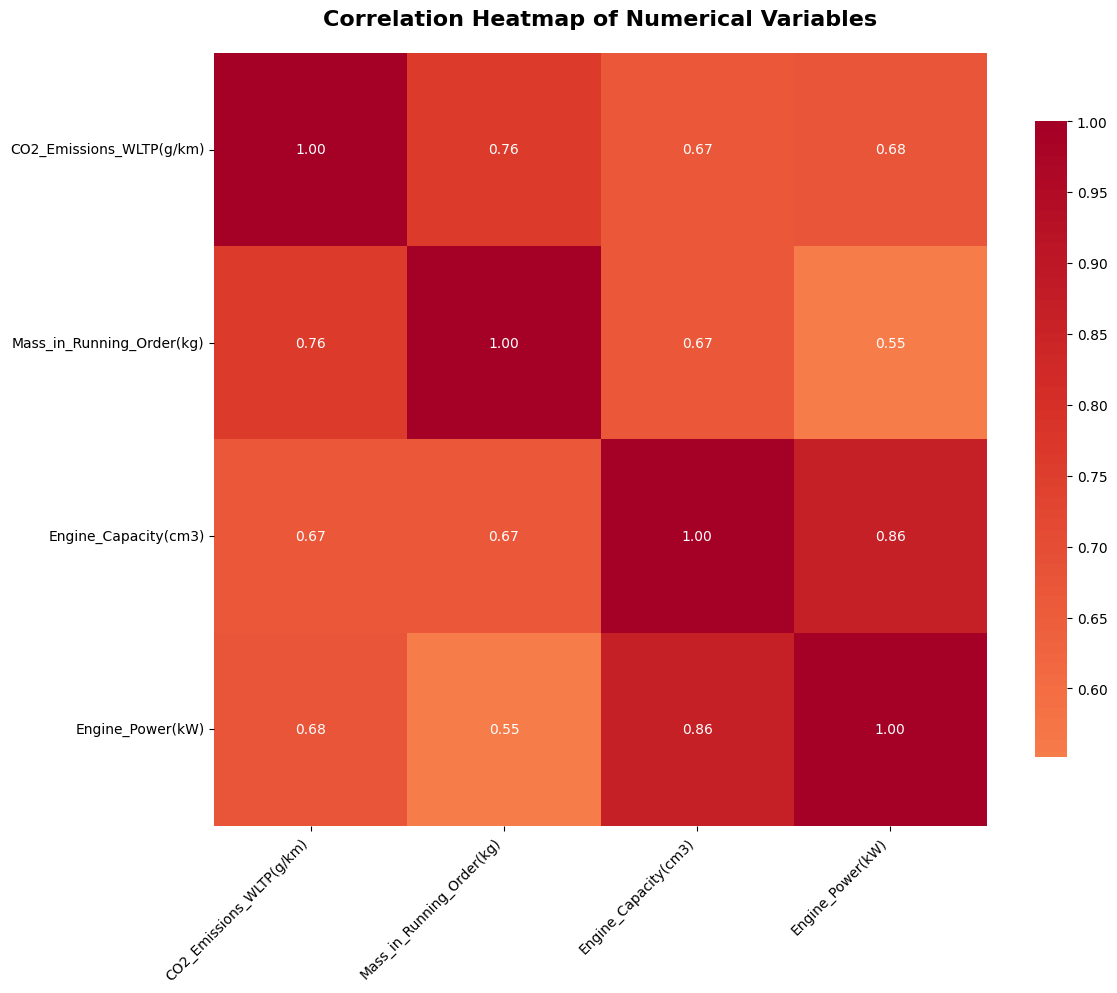

In [152]:
# Correlation analysis with CO2 emissions
# Selecting numerical columns for correlation analysis
numerical_cols = df_merged_clean.select_dtypes(include=[np.number]).columns

#display(numerical_cols)

corr_with_co2 = df_merged_clean[numerical_cols].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
for var, corr_val in corr_with_co2.items():
    print(f"{var:<50} {np.format_float_positional(corr_val, precision=2)}")


# Create correlation matrix for all numerical columns
correlation_matrix = df_merged_clean[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
            center=0,             # Center colormap at 0
            square=True,          # Make cells square-shaped
            fmt='.2f',            # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Exploring and selecting the rest of the variables

In [153]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                                     Column Data Type  Non-Null Count  Null Count  Null Percentage
                                 Vehicle_ID     int64          113821           0              0.0
                                    Country    object          113821           0              0.0
                   Vehicle_Family_id_number    object          107398        6423              5.6
                       Manufacturer_Pooling    object          105214        8607              7.6
                          Manufacturer_Name    object          113821           0              0.0
                      Manufacturer_name_OEM    object          113821           0              0.0
                       Type_approval_number    object          112233        1588              1.4
                                       Type    object          113678         143              0.1
                                    Variant    object          111743        2078              1.8
          

Drop columns: <br>
Vehicle_Family_id_number - the model of the car is already described by other variables <br>
Manufacturer_Pooling - the model of the car is already described by other variables <br>
Manufacturer_Name - the model of the car is already described by other variables <br>
Manufacturer_name_OEM - the model of the car is already described by other variables <br>
Manufacturer_name_MS - the model of the car is already described by other variables <br>
Type_approval_number - the model of the car is already described by other variables <br>
Type - we used it for the filtering but we dont need it anymore <br>
Variant - we used it for the filtering but we dont need it anymore<br>
Version - we used it for the filtering but we dont need it anymore <br>
Make - not relevant for CO2 <br>
Commercial_Name - we used it for the filtering but we dont need it anymore <br>
Category_type_approved - not relevant for CO2 <br>
Category_type_registered - not relevant for CO2 <br>
Total_new_registrations - not relevant for CO2 <br>
Mass_in_Running_Order(kg) - stay <br>
WLTP_test_mass - stay <br>
CO2_Emissions_NEDC(g/km) - the whole is zeros <br>
CO2_Emissions_WLTP(g/km) - our target <br>
Wheelbase(mm) - the whole is zeros <br>
Axle_Track_1(mm) - the whole is zeros <br>
Axle_Track_2(mm) - the whole is zeros<br>
Fuel_Type - we should keep it<br>
Fuel_Mode - stay<br>
Engine_Capacity(cm3) - stay<br>
Engine_Power(kW) - stay<br>
Electric_Energy_Consumption(Wh/km) - not relevant for Combustion<br>
Innovative_Technologies - 35% of zeros, delete<br>
Emmission_reduction_through_innovation - 30& of zeros, delete<br>
Emmission_reduction_through_innovation_WLTP - 30% of zeros, delete<br>
Deviation_factor - 100% of zeros, delete<br>
Verification_factor - 100% of zeros, delete<br>
Status - delete not relevant for study<br>
 year - delete not relevant for study<br>
Date of registration - delete, not relevant for study<br>
Fuel consumption - stay<br>
Electric_Charge - not relevant for Combustion<br>
RLFI - Delete, a lot of zeros
Electric range (km) - delete, not relevant for study<br>

#### Dropping columns that are meaningless

In [154]:
columns_to_drop = ['Vehicle_ID','Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Country',
                   'Type','Variant', 'Version','Commercial_Name', 'Type_approval_number', 'Make', 'Category_type_approved', 
                   'Category_type_registered','Total_new_registrations','Electric_Energy_Consumption(Wh/km)','year',
                   'Emmission_reduction_through_innovation_WLTP',
                   'Status','Date of registration','Electric_Charge','RLFI', 'Electric range (km)' ]

df_unique = df_unique.drop(columns_to_drop, axis=1)

#### what about Fuel mode? what is it behind? <--- FIltering "M"

In [155]:
df_unique['Fuel_Mode'].value_counts()

Fuel_Mode
M    74816
H    38963
F       42
Name: count, dtype: int64

This fuel modes are the way they do the tests in the emission tests. We should stick only to onw of those

Fuel_Mode Codes Explained

| Code | Meaning                        | Description                                                                 |
|------|--------------------------------|-----------------------------------------------------------------------------|
| **M** | **Mixed** or **Combined Mode** | This is the standard test mode combining **urban and extra-urban cycles**, or a **weighted average** of several driving phases (used in WLTP or NEDC cycles). |
| **H** | **High** or **Extra-Urban**    | Refers to higher-speed or **extra-urban driving conditions** (e.g., highway). Often used to isolate performance/emissions in faster driving. |
| **F** | **Full Power / Fast / Urban Cold** (less common) | Could refer to a cold start cycle, or a specific **urban test cycle**, but with only 36 entries it's probably a rare, legacy, or test-specific label. |

In [156]:
df_unique = df_unique[df_unique['Fuel_Mode']== 'M']

In [157]:
df_unique.shape

(74816, 9)

#### Looking for Multicolinearities <--- Deleting Fuel Consumption and Mass WLTP

Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                           1.
Fuel_consumption                                   0.92
WLTP_test_mass                                     0.77
Mass_in_Running_Order(kg)                          0.77
Engine_Capacity(cm3)                               0.65
Engine_Power(kW)                                   0.63


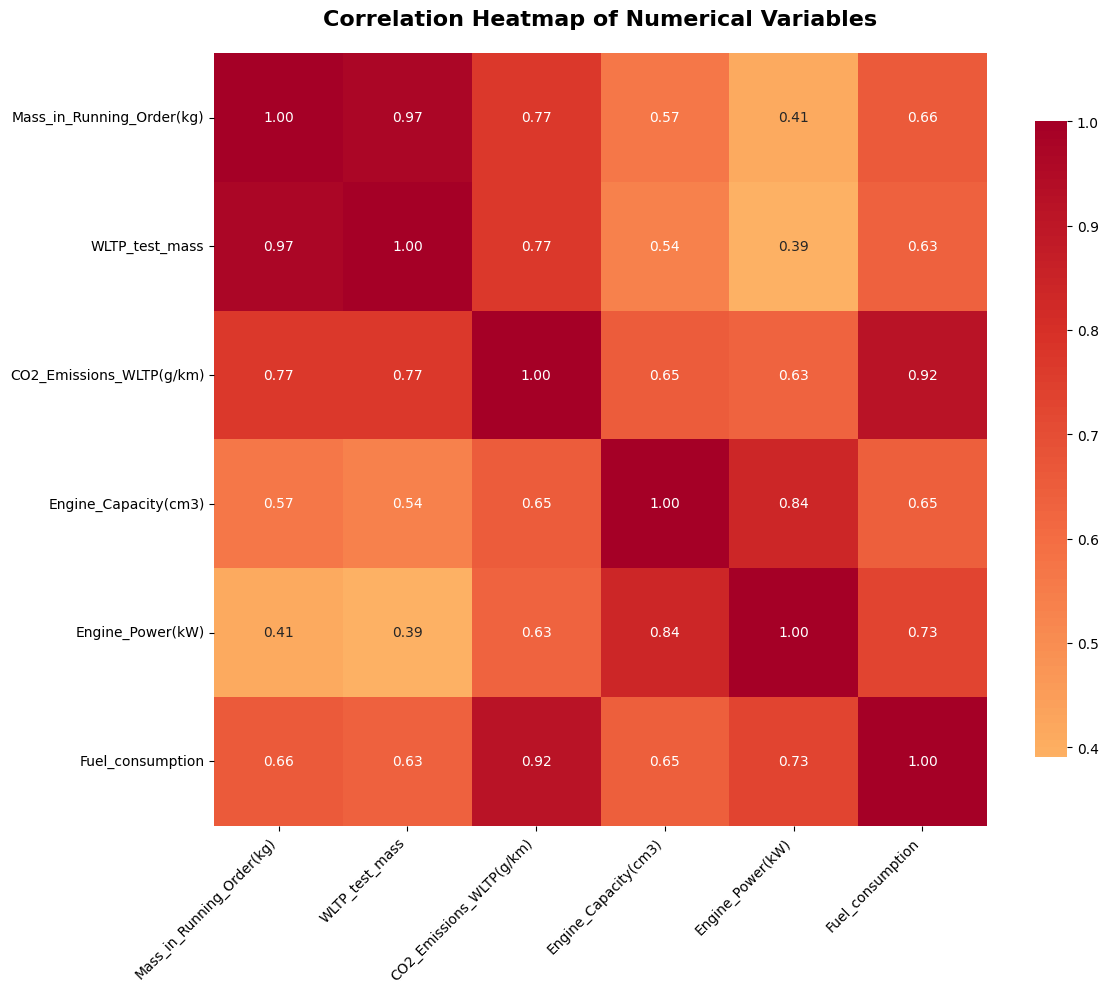

In [158]:
# Correlation analysis with CO2 emissions
# Selecting numerical columns for correlation analysis
numerical_cols = df_unique.select_dtypes(include=[np.number]).columns

#display(numerical_cols)

corr_with_co2 = df_unique[numerical_cols].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
for var, corr_val in corr_with_co2.items():
    print(f"{var:<50} {np.format_float_positional(corr_val, precision=2)}")


# Create correlation matrix for all numerical columns
correlation_matrix = df_unique[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
            center=0,             # Center colormap at 0
            square=True,          # Make cells square-shaped
            fmt='.2f',            # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [159]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Assuming your dataframe is called 'df'
# Select only the numerical features (exclude the target variable CO2(g/km))
features = [
                 'Fuel_consumption',
                 'Engine_Capacity(cm3)',
                 'Engine_Power(kW)',
                 'WLTP_test_mass',
                 'Mass_in_Running_Order(kg)',
]

# Create a subset with only the features
X = df_unique[features]

# Handle any missing values if necessary
X = X.dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by VIF values (descending)
vif_data = vif_data.sort_values('VIF', ascending=False)
print("VIF Values:")
print(vif_data)


VIF Values:
                     Feature   VIF
4  Mass_in_Running_Order(kg) 552.6
3             WLTP_test_mass 486.9
0           Fuel_consumption  52.9
1       Engine_Capacity(cm3)  49.2
2           Engine_Power(kW)  28.1


##### Droping WLTP Mass

serious multi-colinearity between Mass_in_Running_Order(kg) and WLTP_test_mass, we'll delete the one with mroe zeros

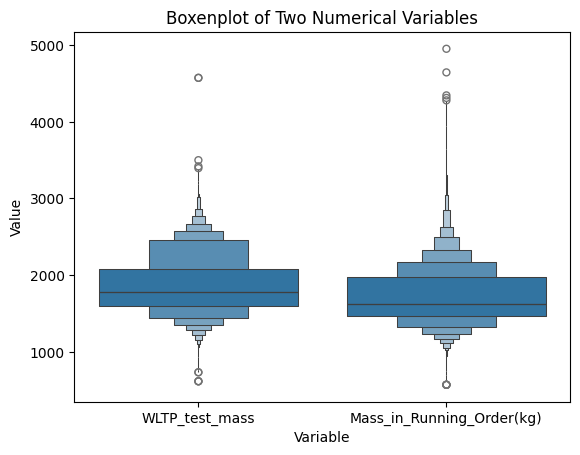

In [160]:

# Pick two numerical columns
cols = ['WLTP_test_mass', 'Mass_in_Running_Order(kg)']

# Melt the data
df_melted = df_unique[cols].melt(var_name='Variable', value_name='Value')

# Plot
sns.boxenplot(x='Variable', y='Value', data=df_melted)
plt.title('Boxenplot of Two Numerical Variables')
plt.show()

In [161]:
#calculating the difference in means
difference_masses = df_unique['WLTP_test_mass'].mean() - df_unique['Mass_in_Running_Order(kg)'].mean() 

In [162]:
df_unique['Mass_in_Running_Order(kg)'] = df_unique['Mass_in_Running_Order(kg)'].fillna(
    df_unique['WLTP_test_mass'] - difference_masses)

In [163]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           74792          24              0.0
           WLTP_test_mass   float64           70467        4349              5.8
 CO2_Emissions_WLTP(g/km)   float64           74816           0              0.0
                Fuel_Type    object           74816           0              0.0
                Fuel_Mode    object           74816           0              0.0
     Engine_Capacity(cm3)   float64           74791          25              0.0
         Engine_Power(kW)   float64           74689         127              0.2
  Innovative_Technologies    object           56771       18045             24.1
         Fuel_consumption   float64           62217       12599             16.8


still some NA in Mass_in_Running_Order(kg), lets drop na values

In [164]:
df_unique=  df_unique.dropna(subset=['Mass_in_Running_Order(kg)'])

In [165]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           74792           0              0.0
           WLTP_test_mass   float64           70467        4325              5.8
 CO2_Emissions_WLTP(g/km)   float64           74792           0              0.0
                Fuel_Type    object           74792           0              0.0
                Fuel_Mode    object           74792           0              0.0
     Engine_Capacity(cm3)   float64           74769          23              0.0
         Engine_Power(kW)   float64           74667         125              0.2
  Innovative_Technologies    object           56768       18024             24.1
         Fuel_consumption   float64           62206       12586             16.8


now we drop the WLTP_test_mass

In [166]:

df_unique = df_unique.drop('WLTP_test_mass', axis=1)

In [167]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           74792           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           74792           0              0.0
                Fuel_Type    object           74792           0              0.0
                Fuel_Mode    object           74792           0              0.0
     Engine_Capacity(cm3)   float64           74769          23              0.0
         Engine_Power(kW)   float64           74667         125              0.2
  Innovative_Technologies    object           56768       18024             24.1
         Fuel_consumption   float64           62206       12586             16.8


##### Dropping Fuel Consumption

Fuel_consumption and CO2 are very high correlated (0.97) and also has 20% of missing data, thus we'll drop it

In [168]:
df_unique = df_unique.drop('Fuel_consumption', axis=1)

In [169]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           74792           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           74792           0              0.0
                Fuel_Type    object           74792           0              0.0
                Fuel_Mode    object           74792           0              0.0
     Engine_Capacity(cm3)   float64           74769          23              0.0
         Engine_Power(kW)   float64           74667         125              0.2
  Innovative_Technologies    object           56768       18024             24.1


In [170]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Assuming your dataframe is called 'df'
# Select only the numerical features (exclude the target variable CO2(g/km))
features = [
                 'Engine_Capacity(cm3)',
                 'Engine_Power(kW)',
                 'Mass_in_Running_Order(kg)',
]

# Create a subset with only the features
X = df_unique[features]

# Handle any missing values if necessary
X = X.dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by VIF values (descending)
vif_data = vif_data.sort_values('VIF', ascending=False)
print("VIF Values:")
print(vif_data)

VIF Values:
                     Feature  VIF
0       Engine_Capacity(cm3) 42.1
1           Engine_Power(kW) 17.2
2  Mass_in_Running_Order(kg) 16.4


#### Deleting Innovative Technlogies <--- It has high cardinality, 30 percent zeros, very low interpretability and low predictive power

In [171]:
df_unique['Innovative_Technologies'].value_counts(normalize=True)

Innovative_Technologies
e1 29       0.3
e8 29 37    0.1
e13 29 37   0.1
e9 29 37    0.1
e1 29 37    0.1
             ..
e1*29       0.0
e2 29  28   0.0
e8 29  28   0.0
e8 28 37    0.0
e637        0.0
Name: proportion, Length: 132, dtype: float64

Innovative Technologies has a very high cardinality and very low interpretability maybe we should drop it. <br>
lets do a quick test to see its predictive power

In [172]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Simple encoding for testing
df_copy = df_unique.copy()
df_copy['Innovative_Technologies'] = df_copy['Innovative_Technologies'].astype(str)
df_copy['Innovative_Technologies'] = df_copy['Innovative_Technologies'].astype('category').cat.codes

X = df_copy[['Innovative_Technologies']]
y = df_copy['CO2_Emissions_WLTP(g/km)']  

clf = RandomForestClassifier()
score = cross_val_score(clf, X, y, cv=5).mean()
print("Mean CV Accuracy:", score)

/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Mean CV Accuracy: 0.0376911957085249


This confirms what we said, this variable should be deleted

In [173]:
df_unique = df_unique.drop('Innovative_Technologies', axis = 1)

### Handling Zeros


In [174]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           74792           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           74792           0              0.0
                Fuel_Type    object           74792           0              0.0
                Fuel_Mode    object           74792           0              0.0
     Engine_Capacity(cm3)   float64           74769          23              0.0
         Engine_Power(kW)   float64           74667         125              0.2


In [175]:
df_unique=  df_unique.dropna(subset=['Engine_Capacity(cm3)','Engine_Power(kW)'])

In [176]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           74664           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           74664           0              0.0
                Fuel_Type    object           74664           0              0.0
                Fuel_Mode    object           74664           0              0.0
     Engine_Capacity(cm3)   float64           74664           0              0.0
         Engine_Power(kW)   float64           74664           0              0.0


## **TARGET VARIABLE ANALYSIS: CO2 (g/km)** - after filtering

In [177]:
### TARGET VARIABLE ANALYSIS: CO2 (g/km)

display(df_unique['CO2_Emissions_WLTP(g/km)'].describe())

count   74664.0
mean      167.4
std        43.4
min         1.0
25%       135.0
50%       156.0
75%       194.0
max       543.0
Name: CO2_Emissions_WLTP(g/km), dtype: float64

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_56298/1977143025.py:25: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


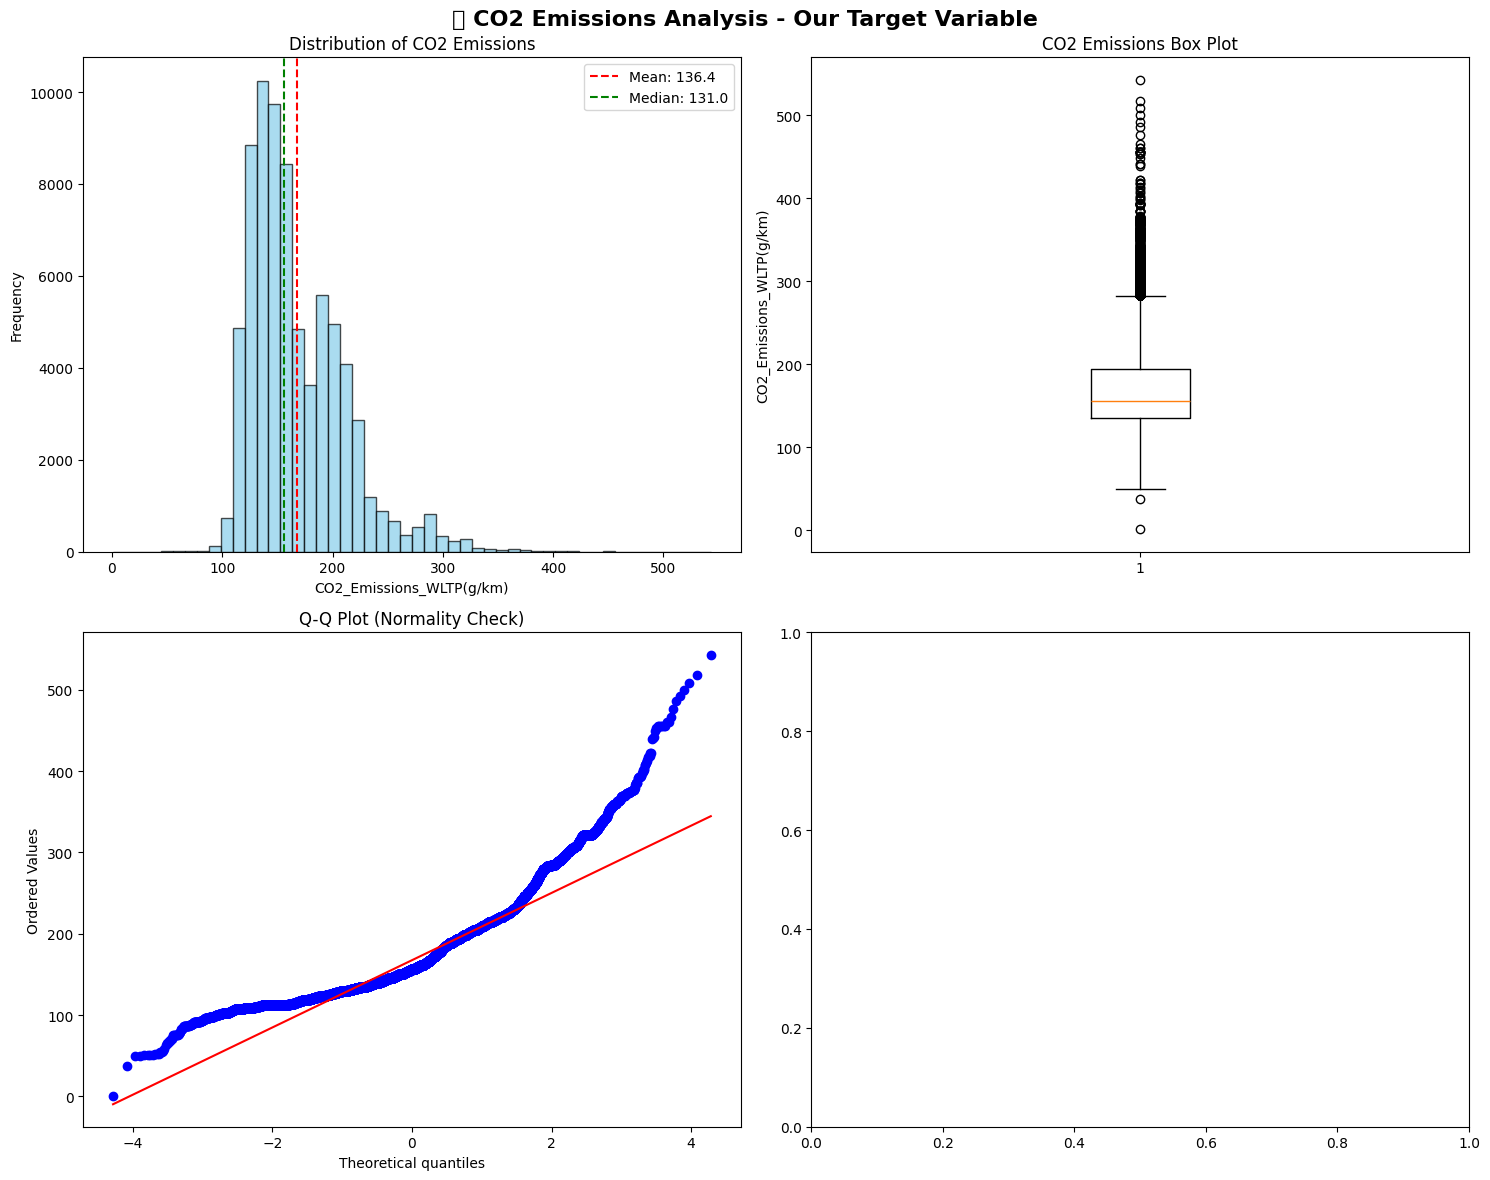

In [178]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df_unique['CO2_Emissions_WLTP(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df_unique['CO2_Emissions_WLTP(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df_a["CO2_Emissions_WLTP(g/km)"].mean():.1f}')
axes[0,0].axvline(df_unique['CO2_Emissions_WLTP(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df_a["CO2_Emissions_WLTP(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df_unique['CO2_Emissions_WLTP(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2_Emissions_WLTP(g/km)')

# Q-Q plot for normality
stats.probplot(df_unique['CO2_Emissions_WLTP(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')



plt.tight_layout()
plt.show()

Q-Q PLOT: The data shows that the Distribution is not Normal, we should consider this for the model steps. We should use a model that does not suppose normal distribution

In [179]:
df_a.shape

(7870432, 32)

## Does <span style="color:orange"> Engine Capacity </span> has a relationship with CO2 Emissions

- Null Hypothesis (H₀): There is no linear relationship between engine capacity and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between engine capacity and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: 0.648583
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.509755
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Strong positive linear relationship
Spearman: Strong positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.420660
   Interpretation: 42.07% of variance in CO2 emissions is explained by engine capacity


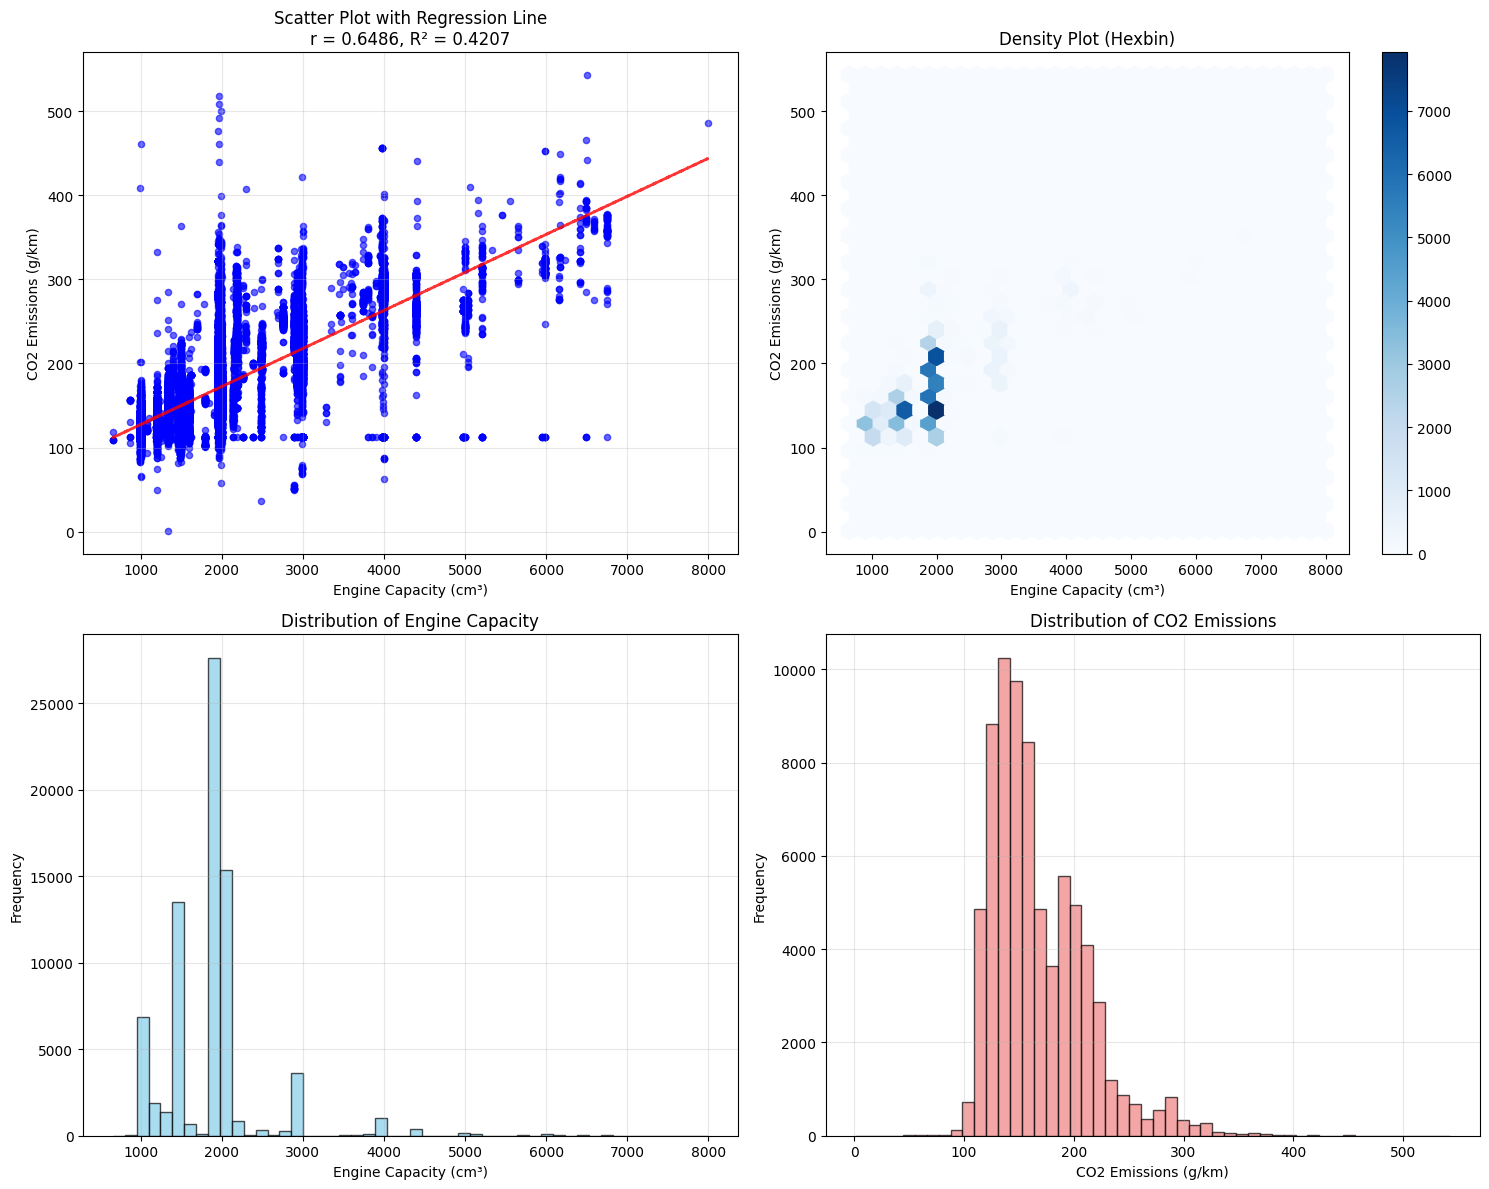


=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is strong and positive.
Engine capacity explains 42.07% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.5098) is much different from Pearson correlation (0.6486),
this suggests a non-linear monotonic relationship might exist.


In [180]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by engine capacity")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_unique['Engine_Capacity(cm3)'], p(df_unique['Engine_Capacity(cm3)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Engine Capacity (cm³)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Engine Capacity (cm³)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_unique['Engine_Capacity(cm3)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Engine Capacity (cm³)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Engine Capacity')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_unique['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

## Does <span style="color:orange"> Engine Power </span> have a relationship with CO2 Emissions

- Null Hypothesis (H₀): There is no linear relationship between fuel consumoption and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between fuel consumoption and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== ENGINE POWER AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: 0.634329
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.633979
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Strong positive linear relationship
Spearman: Strong positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.402373
   Interpretation: 40.24% of variance in CO2 emissions is explained by engine capacity


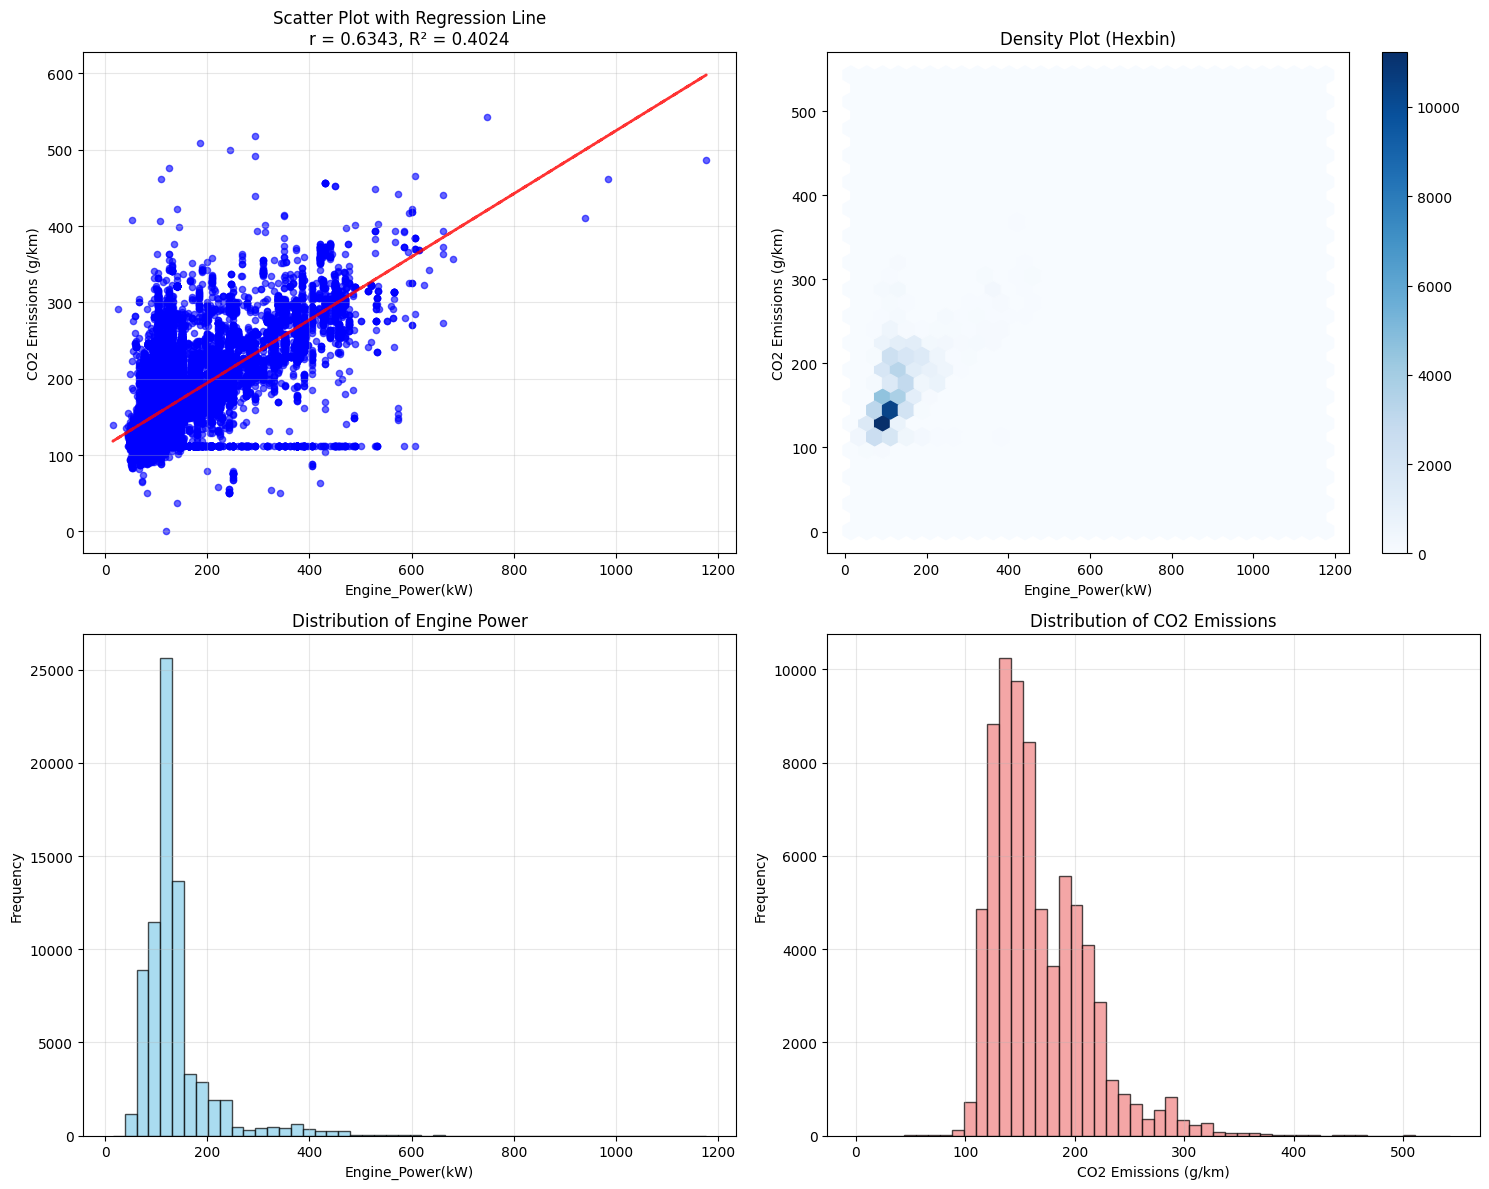


=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is strong and positive.
Engine capacity explains 40.24% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.6340) is much different from Pearson correlation (0.6343),
this suggests a non-linear monotonic relationship might exist.


In [181]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== ENGINE POWER AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by engine capacity")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_unique['Engine_Power(kW)'], p(df_unique['Engine_Power(kW)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Engine_Power(kW)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Engine_Power(kW)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_unique['Engine_Power(kW)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Engine_Power(kW)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Engine Power')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_unique['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

## Does <span style="color:orange"> Mass </span> have a relationship with CO2 Emissions

- Null Hypothesis (H₀): There is no linear relationship between Mass and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between Mass and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased Mass.

=== MASS AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: 0.771281
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.790024
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Very Strong positive linear relationship
Spearman: Very Strong positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.594874
   Interpretation: 59.49% of variance in CO2 emissions is explained by mass


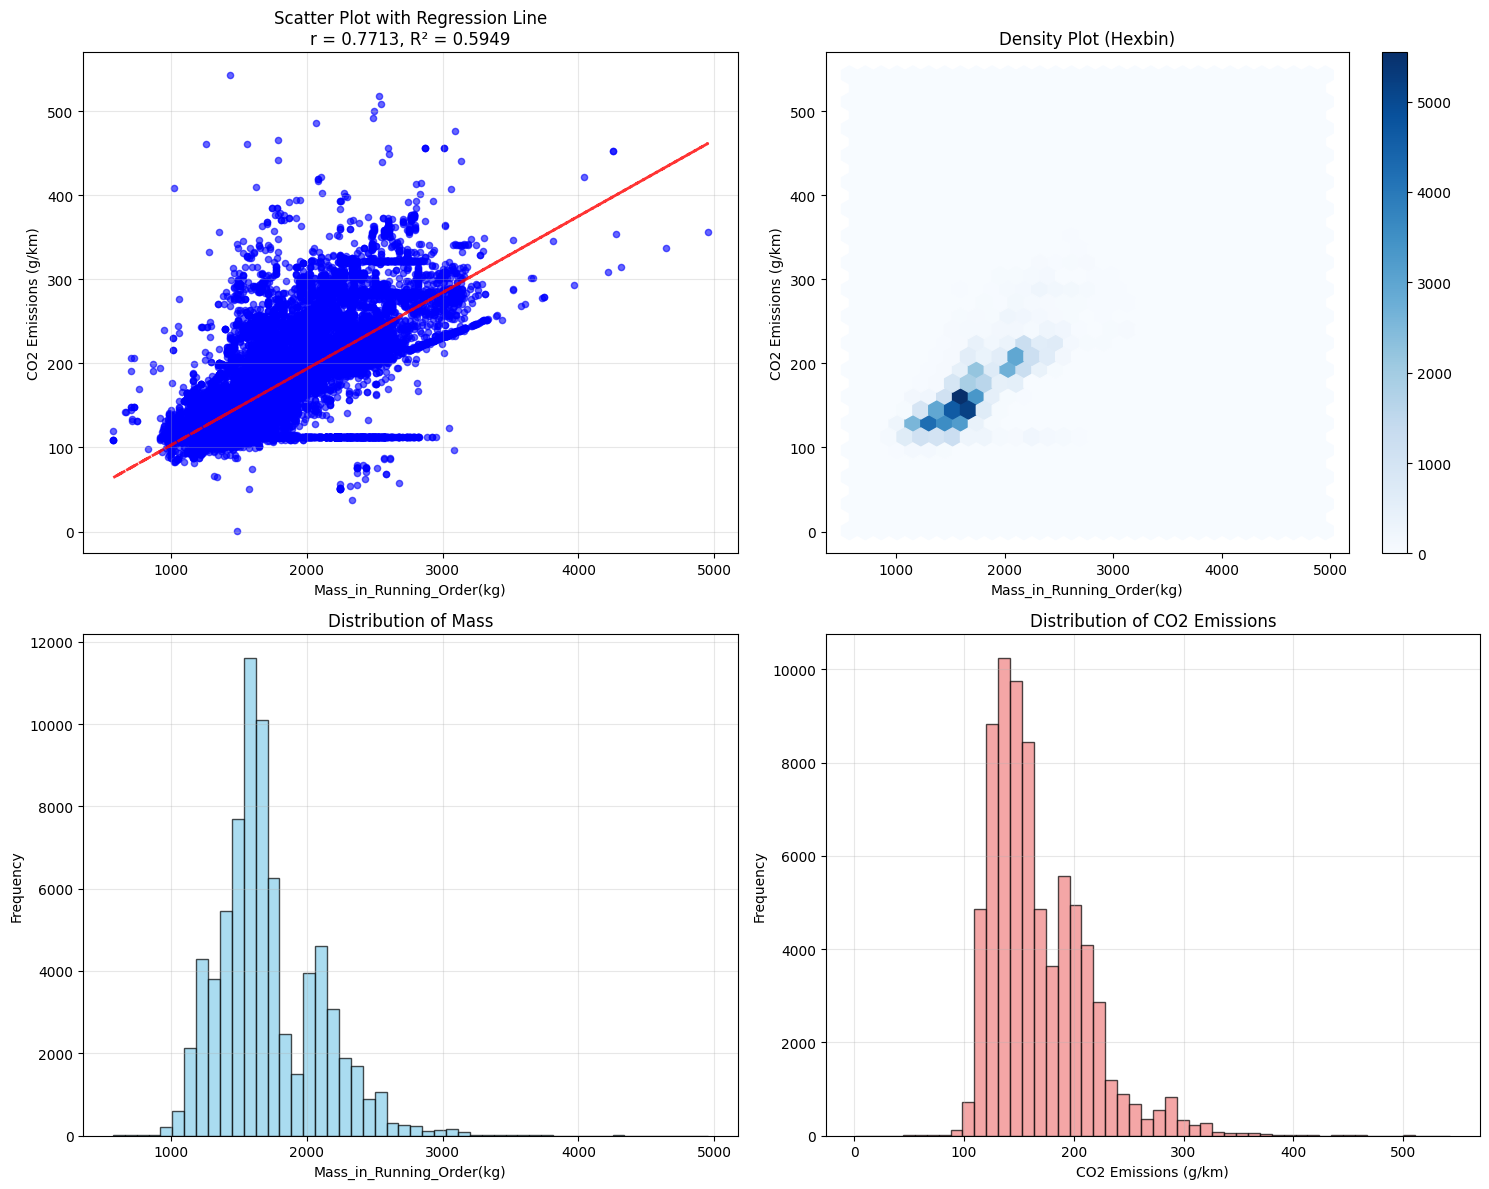


=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is very strong and positive.
Engine capacity explains 59.49% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.7900) is much different from Pearson correlation (0.7713),
this suggests a non-linear monotonic relationship might exist.


In [182]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== MASS AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by mass")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_unique['Mass_in_Running_Order(kg)'], p(df_unique['Mass_in_Running_Order(kg)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Mass_in_Running_Order(kg)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Mass_in_Running_Order(kg)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_unique['Mass_in_Running_Order(kg)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Mass_in_Running_Order(kg)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Mass')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_unique['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

### DF After Variable Reduction

In [183]:
df_unique.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
0,1301.0,143.0,petrol,M,999.0,81.0
3,1316.0,131.0,petrol,M,1332.0,103.0
5,1358.0,144.0,petrol,M,1498.0,110.0
6,1171.0,127.0,petrol,M,999.0,67.0
7,1478.0,118.0,diesel,M,1968.0,110.0


In [184]:
df_unique['Fuel_Type'].value_counts(normalize=True)

Fuel_Type
diesel   0.5
petrol   0.5
Name: proportion, dtype: float64

In [185]:
df_unique.shape

(74664, 6)

## Handling Outliers

### For CO2 <--- Deleting lower bound

In [186]:
Q1 = df_unique['CO2_Emissions_WLTP(g/km)'].quantile(0.25)
Q3 = df_unique['CO2_Emissions_WLTP(g/km)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['CO2_Emissions_WLTP(g/km)'] < lower_bound) |
    (df_unique['CO2_Emissions_WLTP(g/km)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 1982


In [187]:
outliers_iqr

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
128,2235.0,304.0,petrol,M,3996.0,349.0
411,2485.0,294.0,petrol,M,3996.0,404.0
707,2330.0,324.0,petrol,M,5980.0,450.0
874,2595.0,363.0,petrol,M,3982.0,430.0
1948,2595.0,363.0,petrol,M,3982.0,430.0
...,...,...,...,...,...,...
10721374,2595.0,283.0,petrol,M,3982.0,430.0
10722203,2765.0,285.0,petrol,M,6749.0,420.0
10722603,2785.0,290.0,petrol,M,6749.0,441.0
10726356,2785.0,286.0,petrol,M,6749.0,441.0


In [188]:
df_unique[df_unique['CO2_Emissions_WLTP(g/km)'] < lower_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
1239778,2333.0,37.0,petrol,M,2488.0,141.0
5703024,1485.0,1.0,petrol,M,1332.0,120.0


We'll delete this two

In [189]:
df_unique = df_unique[~(df_unique['CO2_Emissions_WLTP(g/km)'] < lower_bound)]

### for Engine Capacity <--- Nothing to delete

In [190]:
Q1 = df_unique['Engine_Capacity(cm3)'].quantile(0.25)
Q3 = df_unique['Engine_Capacity(cm3)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['Engine_Capacity(cm3)'] < lower_bound) |
    (df_unique['Engine_Capacity(cm3)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 5991


In [191]:
df_unique[df_unique['Engine_Capacity(cm3)'] < lower_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
109004,570.0,109.0,petrol,M,658.0,63.0
1107221,570.0,119.0,petrol,M,658.0,63.0
2157778,570.0,109.0,petrol,M,658.0,62.0
9719378,570.0,109.0,petrol,M,658.0,63.0
9772171,570.0,109.0,petrol,M,658.0,63.0


In [192]:
df_unique[df_unique['Engine_Capacity(cm3)'] < upper_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
0,1301.0,143.0,petrol,M,999.0,81.0
3,1316.0,131.0,petrol,M,1332.0,103.0
5,1358.0,144.0,petrol,M,1498.0,110.0
6,1171.0,127.0,petrol,M,999.0,67.0
7,1478.0,118.0,diesel,M,1968.0,110.0
...,...,...,...,...,...,...
10734267,1570.0,121.0,petrol,M,1498.0,110.0
10734360,1458.0,126.0,petrol,M,1984.0,180.0
10734471,1870.0,125.0,diesel,M,1950.0,143.0
10734482,1418.0,111.0,petrol,M,1498.0,110.0


<Axes: ylabel='Engine_Capacity(cm3)'>

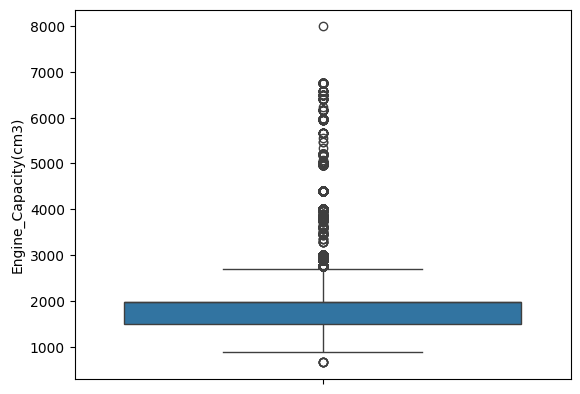

In [193]:
sns.boxplot(df_unique['Engine_Capacity(cm3)'])

Everything seems to be alright

### for Engine Power <--- Nothing to delete

In [194]:
Q1 = df_unique['Engine_Power(kW)'].quantile(0.25)
Q3 = df_unique['Engine_Power(kW)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['Engine_Power(kW)'] < lower_bound) |
    (df_unique['Engine_Power(kW)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 6408


In [195]:
df_unique[df_unique['Engine_Power(kW)'] < lower_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
1301693,1425.0,139.0,petrol,M,1482.0,15.0
4446097,1950.0,292.0,petrol,M,3982.0,26.0


In [196]:
df_unique[df_unique['Engine_Power(kW)'] > upper_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
9,1620.0,247.0,petrol,M,2981.0,353.0
27,2585.0,266.0,petrol,M,4395.0,390.0
28,2335.0,269.0,petrol,M,4395.0,390.0
30,2085.0,245.0,petrol,M,2993.0,375.0
115,1628.0,205.0,petrol,M,1984.0,221.0
...,...,...,...,...,...,...
10733830,1440.0,156.0,petrol,M,1988.0,220.0
10733920,2080.0,183.0,petrol,M,2894.0,243.0
10733952,2204.0,203.0,petrol,M,1997.0,221.0
10734000,2810.0,177.0,petrol,M,2996.0,294.0


<Axes: ylabel='Engine_Power(kW)'>

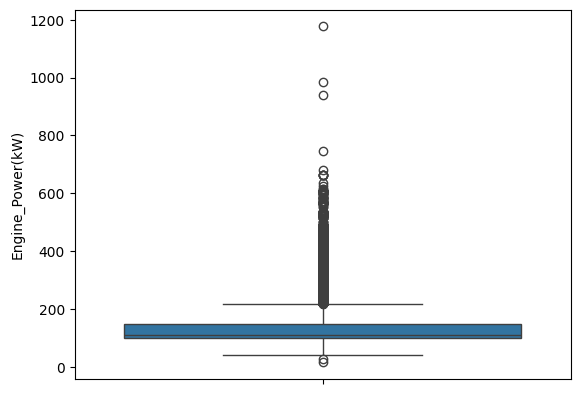

In [197]:
sns.boxplot(df_unique['Engine_Power(kW)'])

### for Mass <--- Nothing to delete

In [198]:
Q1 = df_unique['Mass_in_Running_Order(kg)'].quantile(0.25)
Q3 = df_unique['Mass_in_Running_Order(kg)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['Mass_in_Running_Order(kg)'] < lower_bound) |
    (df_unique['Mass_in_Running_Order(kg)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 951


In [199]:
df_unique[df_unique['Mass_in_Running_Order(kg)'] < lower_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
98206,700.0,148.0,petrol,M,1999.0,128.0
109004,570.0,109.0,petrol,M,658.0,63.0
1107221,570.0,119.0,petrol,M,658.0,63.0
1393181,700.0,148.0,petrol,M,1999.0,128.0
1663280,668.0,142.0,petrol,M,1598.0,77.0
1681113,700.0,145.0,petrol,M,1596.0,100.0
2157778,570.0,109.0,petrol,M,658.0,62.0
2283848,710.0,131.0,petrol,M,1497.0,90.0
2491675,700.0,206.0,petrol,M,1999.0,177.0
2607900,658.0,142.0,petrol,M,1598.0,77.0


In [200]:
df_unique[df_unique['Mass_in_Running_Order(kg)'] > upper_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
8483,2762.0,322.0,diesel,M,1950.0,140.0
9617,2740.0,311.0,diesel,M,2993.0,183.0
9942,2815.0,313.0,diesel,M,2993.0,183.0
9998,2740.0,332.0,petrol,M,2998.0,210.0
11807,2815.0,312.0,diesel,M,2993.0,183.0
...,...,...,...,...,...,...
10722954,2725.0,205.0,petrol,M,4395.0,390.0
10726356,2785.0,286.0,petrol,M,6749.0,441.0
10729173,2785.0,287.0,petrol,M,6749.0,441.0
10729985,2803.0,205.0,petrol,M,4395.0,390.0


<Axes: ylabel='Mass_in_Running_Order(kg)'>

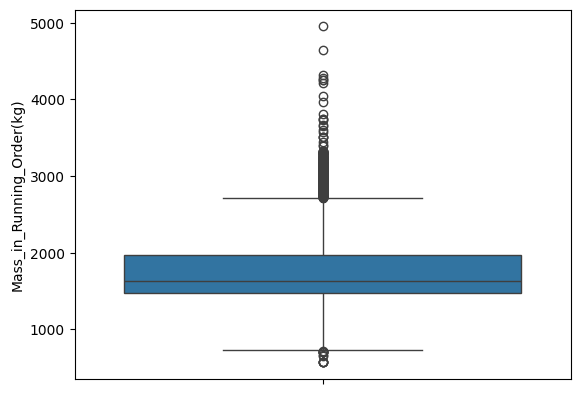

In [201]:
sns.boxplot(df_unique['Mass_in_Running_Order(kg)'])